In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [2]:

iris = load_iris(as_frame=True)
df = iris.frame

print(df.head())
print("Dataset shape:", df.shape)
print("Flower names:", iris.target_names)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Dataset shape: (150, 5)
Flower names: ['setosa' 'versicolor' 'virginica']


In [3]:

print(df.describe())
print(df["target"].value_counts())


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  
target
0    50
1    50
2    50
Name: count, dtype: int64


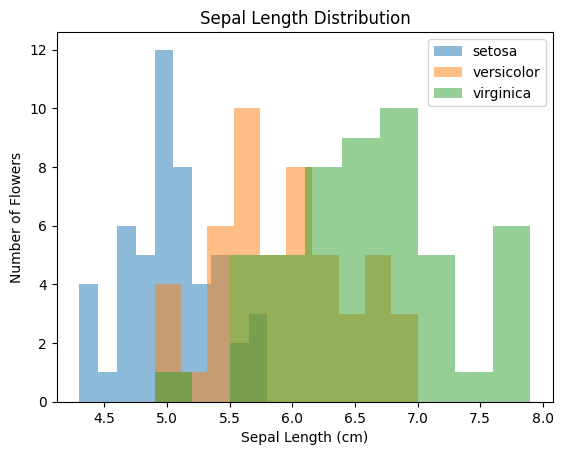

In [4]:

for i, name in enumerate(iris.target_names):
    data = df[df["target"] == i]
    plt.hist(data["sepal length (cm)"], alpha=0.5, label=name)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Number of Flowers")
plt.title("Sepal Length Distribution")
plt.legend()
plt.show()


In [5]:

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


In [6]:

model1 = LogisticRegression(max_iter=200)
model2 = RandomForestClassifier(random_state=42)

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

print("Both models trained successfully!")


Both models trained successfully!


In [7]:

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

print("Logistic Regression Accuracy:", round(acc1 * 100, 2), "%")
print("Random Forest Accuracy:", round(acc2 * 100, 2), "%")

if acc1 >= acc2:
    best_model = model1
    best_pred = pred1
    best_name = "Logistic Regression"
else:
    best_model = model2
    best_pred = pred2
    best_name = "Random Forest"

print("Best model:", best_name)


Logistic Regression Accuracy: 96.67 %
Random Forest Accuracy: 90.0 %
Best model: Logistic Regression


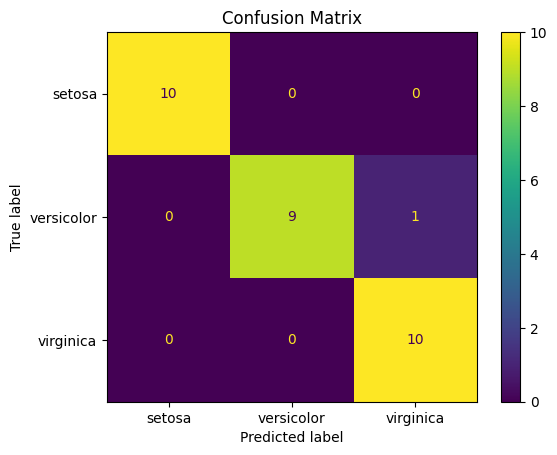

In [8]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=iris.target_names
)

plt.title("Confusion Matrix")
plt.show()


In [9]:

print(classification_report(
    y_test,
    best_pred,
    target_names=iris.target_names
))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [10]:

print("PROJECT CONCLUSION")
print("Iris flower classification was completed successfully.")
print("Two machine learning models were compared.")
print("The best model was:", best_name)
print("Its accuracy is:", round(max(acc1, acc2) * 100, 2), "%")


PROJECT CONCLUSION
Iris flower classification was completed successfully.
Two machine learning models were compared.
The best model was: Logistic Regression
Its accuracy is: 96.67 %
